# LR range test (발산 임계 진단)

최종 8192 런에 쓸 lr이 발산 임계 대비 어디에 있는지만 잰다. 최적 lr을 고르는 도구가 아니다.

`eff_batch 128 · lr 4.8e-4`는 len512에서만 안전이 확인됐다. len8192는 같은 eff_batch라도 배치에 담기는 토큰이 16배라 스텝당 기울기 잡음과 발산 임계가 다를 수 있다.

판정은 절대값이 아니라 상대 위치로 한다. `11_01`이 같은 lr로 완주한 len512를 대조로 함께 재고,
len8192에서 운영 lr이 전환점 대비 같은 위치인지 본다.

In [1]:
import sys
sys.path.insert(0, "src")  # /workspace/src

import numpy as np
from transformers import TrainerCallback, TrainingArguments

from patent_train import TrainingRunner, TrainConfig, LossTrainer, build_loss, probe_batches

OPERATING_LR = 4.8e-4   # 판정 대상


In [2]:
def probe_cfg(max_len, micro_batch):
    """프로브 config — 최종 런과 같은 레시피 축을 담는다.

    lr 축(learning_rate·warmup_ratio·lr_scheduler_type)과 epochs는 아래 `LrRangeRunner`가
    대체하므로 여기 값은 쓰이지 않는다. weight_decay·eff_batch·seed·백본·손실은 그대로 쓰인다.
    """
    return TrainConfig(
        backbone="axenc",
        loss="focal",
        loss_params={"alpha": 0.25, "gamma": 2},
        max_len=max_len,
        eff_batch=128,                 # 최종 런과 동일 — 발산 임계는 배치에 의존한다
        micro_batch=micro_batch,       # 메모리 상한(길이별) → grad_accum이 유도됨
        eval_micro_batch=micro_batch,  # 프로브는 eval을 하지 않는다
        learning_rate=OPERATING_LR,    # 판정 대상. constant lr. 
        weight_decay=0.01,             # 최종 런과 동일
        warmup_ratio=0.0,              # 프로브는 warmup 없음
        epochs=1,                      # max_steps가 지배한다
        early_stop_epochs=1,           # early stop 없음
        # splits는 좁히지 않는다 — 위 함정 참조(prep 캐시가 최종 풀런에 재사용된다)
        notebook_name="15_01_LRRangeTest.ipynb",
        tag=f"lrrange-axenc-len{max_len}-b128",
        run_name=f"lrrange_axenc_len{max_len}_eff128",
        repo_final="(unused)",         # push 없음
        out_path=f"/workspace/output/lrrange-len{max_len}",
    )


## 프로브 — `TrainingRunner.build_trainer` 오버라이딩

In [3]:
class LrProbe(TrainerCallback):
    """스텝마다 lr을 지수적으로 올리고 손실을 기록한다.

    `lr_scheduler_type="constant"`로 두고 optimizer의 `param_groups`에 직접 쓴다 — HF는
    `on_step_begin` → `optimizer.step()` → `lr_scheduler.step()` 순서라 여기서 쓴 값이 그 스텝의
    실효 lr이 되고, 스케줄러가 되돌린 값은 다음 `on_step_begin`이 다시 덮는다.
    """

    def __init__(self, start_lr=1e-6, end_lr=1e-2, num_steps=300, beta=0.98, diverge=4.0):
        self.start, self.end, self.num_steps = start_lr, end_lr, num_steps
        self.beta, self.diverge = beta, diverge
        self.mult = (end_lr / start_lr) ** (1.0 / max(1, num_steps - 1))
        self.lrs, self.losses, self.smoothed, self.applied = [], [], [], []
        self._ema, self._best, self._cur = None, float("inf"), start_lr
        self.stopped_at = None

    def on_step_begin(self, args, state, control, optimizer=None, **kw):
        self._cur = self.start * self.mult ** state.global_step
        for g in optimizer.param_groups:
            g["lr"] = self._cur
        self.applied.append(float(optimizer.param_groups[0]["lr"]))   # 되읽기(주입 확인용)

    def on_log(self, args, state, control, logs=None, **kw):
        if not logs or "loss" not in logs:
            return
        loss = float(logs["loss"])
        self._ema = loss if self._ema is None else self.beta * self._ema + (1 - self.beta) * loss
        n = len(self.losses) + 1
        sm = self._ema / (1 - self.beta ** n)          # EMA + bias 보정(원시 손실은 배치마다 튄다)
        self.lrs.append(self._cur)
        self.losses.append(loss)
        self.smoothed.append(sm)
        self._best = min(self._best, sm)
        if n >= 15 and sm > self._best * self.diverge:  # 표준 LR finder 중단 규칙
            self.stopped_at = self._cur
            control.should_training_stop = True


In [4]:
class LrRangeRunner(TrainingRunner):
    """`build_trainer`만 오버라이딩한 프로브 러너 — 나머지 단계는 패키지 코드를 그대로 쓴다."""

    def __init__(self, cfg, *, start_lr=1e-6, end_lr=1e-2, num_steps=300):
        super().__init__(cfg)
        self.probe = LrProbe(start_lr, end_lr, num_steps)

    def build_trainer(self):
        cfg, p = self.cfg, self.probe
        n_docs = p.num_steps * cfg.eff_batch
        print(f"[lr-range] {p.start:.1e} -> {p.end:.1e} · {p.num_steps} step"
              f" (스텝당 x{p.mult:.4f}) · len{cfg.max_len} · eff_batch {cfg.eff_batch}"
              f" (micro {cfg.micro_batch} x accum {cfg.grad_accum})")
        print(f"[lr-range] {n_docs:,}문서"
              f" ≈ {n_docs / len(self.data.dataset['train']):.3f} epoch")

        args = TrainingArguments(
            output_dir=cfg.output_dir,
            seed=cfg.seed,
            # lr 축 — 콜백이 지배한다. HF 기본값(5e-5 · linear 감쇠)이 끼지 않도록 명시한다.
            # 콜백이 동작하지 않으면 런 전체가 start_lr로 돌아 평탄 곡선으로 드러난다.
            learning_rate=p.start,
            lr_scheduler_type="constant",
            warmup_ratio=0.0,
            # 최종 런과 같아야 하는 축(HF 기본값과 다른 것만 명시)
            weight_decay=cfg.weight_decay,
            per_device_train_batch_size=cfg.micro_batch,
            gradient_accumulation_steps=cfg.grad_accum,
            train_sampling_strategy="group_by_length",
            remove_unused_columns=False,
            bf16=self.backbone.bf16,
            # 프로브 전용 — eval·save·early stop·wandb 없음
            max_steps=p.num_steps,
            eval_strategy="no",
            save_strategy="no",
            logging_dir=cfg.logging_dir,
            logging_steps=1,          # HF 기본 500 — 스텝마다 손실을 받아야 곡선이 생긴다
            report_to="none",
        )
        self.trainer = LossTrainer(
            model=self.model,
            args=args,
            train_dataset=self.data.dataset["train"],
            data_collator=self.data.collator,
            processing_class=self.data.tokenizer,
            callbacks=[self.probe],
            loss_fn=build_loss(cfg.loss, **cfg.loss_params),
        )
        return self


In [5]:
def read_curve(runner, operating_lr=OPERATING_LR):
    """평활 곡선에서 최급하강 지점과 최저점(=②→③ 전환점)을 읽는다."""
    p = runner.probe
    lr, sm = np.asarray(p.lrs), np.asarray(p.smoothed)
    i_min = int(sm.argmin())
    i_steep = (int(np.gradient(sm[:i_min + 1], np.log10(lr[:i_min + 1])).argmin())
               if i_min >= 2 else i_min)
    r = {
        "tag": runner.cfg.tag, "max_len": runner.cfg.max_len, "eff_batch": runner.cfg.eff_batch,
        "n_steps": len(lr), "lr_first": float(lr[0]), "lr_last": float(lr[-1]),
        "lr_at_steepest": float(lr[i_steep]),
        "lr_at_min_loss": float(lr[i_min]),         # 발산 임계
        "min_smoothed": float(sm[i_min]),
        "lr_at_stop": p.stopped_at,
        "operating_lr": operating_lr,
        "headroom_x": round(float(lr[i_min]) / operating_lr, 2),   # 전환점이 운영 lr의 몇 배
        "curve": {"lr": p.lrs, "loss": p.losses, "smoothed": p.smoothed},
    }
    print(f"[{r['tag']}] len{r['max_len']} · {r['n_steps']} step"
          f" · 주입 lr {p.applied[0]:.2e} ~ {p.applied[-1]:.2e}")
    print(f"  관측 구간 {r['lr_first']:.2e} ~ {r['lr_last']:.2e}"
          + (f" (발산 중단 {r['lr_at_stop']:.2e})" if r["lr_at_stop"] else ""))
    print(f"  ② 최급하강 lr {r['lr_at_steepest']:.3e}")
    print(f"  ②->③ 전환점(발산 임계) lr {r['lr_at_min_loss']:.3e}"
          f" · 평활 손실 최저 {r['min_smoothed']:.5f}")
    print(f"  운영 lr {operating_lr:.2e} -> 전환점이 그 {r['headroom_x']}배")
    return r


def compare(control, target, tolerance_x=1.5):
    """검증된 조합(control)과 대상 조합(target)에서 운영 lr의 상대 위치를 대면시킨다.

    control은 이 lr로 풀런이 완주한 조합이어야 한다 — 그 상대 위치가 "안전하다고 실증된 위치"의
    기준이 된다. 판정은 절대 임계가 아니라 두 위치의 비로 한다.
    """
    lr0 = control["operating_lr"]
    ratio = target["headroom_x"] / control["headroom_x"]
    if ratio >= 1.0 / tolerance_x:
        verdict = "여유 있음: 운영 lr 그대로"
    elif target["headroom_x"] > 1.0:
        verdict = f"경계: control과 같은 위치가 되도록 lr을 {ratio:.2f}배로 낮출 것"
    else:
        verdict = "위험: 운영 lr이 전환점 이상. 이 레시피를 대상 조합에 쓰지 않는다"
    out = {
        "operating_lr": lr0, "tolerance_x": tolerance_x,
        "control_len": control["max_len"], "control_headroom_x": control["headroom_x"],
        "target_len": target["max_len"], "target_headroom_x": target["headroom_x"],
        "headroom_ratio": round(ratio, 3),
        "suggested_lr": round(lr0 * min(1.0, ratio), 8),
        "verdict": verdict,
    }
    print(f"control len{control['max_len']}: 전환점 {control['lr_at_min_loss']:.3e}"
          f" = 운영 lr의 {control['headroom_x']}배")
    print(f"target  len{target['max_len']}: 전환점 {target['lr_at_min_loss']:.3e}"
          f" = 운영 lr의 {target['headroom_x']}배")
    print(f"상대 위치 비 {out['headroom_ratio']:.3f} -> {verdict}")
    if out["suggested_lr"] < lr0:
        print(f"제안 lr {out['suggested_lr']:.3e}")
    return out


## 대조 — len512 (검증된 조합)

In [6]:
r512 = LrRangeRunner(probe_cfg(max_len=512, micro_batch=128))
r512.load_data()
r512.prepare_data()
r512.load_model()

[skip] prep 캐시 존재 — 원본 로드 생략: /workspace/prep_cache/axenc_len512


[transformers] Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertForSequenceClassification is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `dtype` argument. Example: `model = AutoModel.from_pretrained("meta-llama/Llama-3.2-1B", attn_implementation="flash_attention_2", dtype=torch.float16)`
[transformers] Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `dtype` argument. Example: `model = AutoModel.from_pretrained("meta-llama/Llama-3.2-1B", attn_implementation="flash_attention_2", dtype=torch.float16)`


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: skt/A.X-Encoder-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[model] skt/A.X-Encoder-base@9708f9c4(신규 헤드)


In [7]:
r512.build_trainer()
r512.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


[lr-range] 1.0e-06 -> 1.0e-02 · 300 step (스텝당 x1.0313) · len512 · eff_batch 128 (micro 128 x accum 1)
[lr-range] 38,400문서 ≈ 0.190 epoch


Step,Training Loss
1,0.094791
2,0.094280
3,0.093831
4,0.093022
5,0.093145
6,0.091982
7,0.092111
8,0.092255
9,0.092559
10,0.089785


In [8]:
res512 = read_curve(r512)

[lrrange-axenc-len512-b128] len512 · 300 step · 주입 lr 1.00e-06 ~ 1.00e-02
  관측 구간 1.00e-06 ~ 1.00e-02
  ② 최급하강 lr 1.000e-06
  ②->③ 전환점(발산 임계) lr 8.841e-03 · 평활 손실 최저 0.00423
  운영 lr 4.80e-04 -> 전환점이 그 18.42배


## 본 — len8192

`micro_batch`는 메모리 상한이라 실측으로 정한다. 아래 셀로 안전 상한을 확인한 뒤 `probe_cfg`에 넣는다.


In [12]:
r8k = LrRangeRunner(probe_cfg(max_len=8192, micro_batch=8))   # OOM 확인 결과로 조정
r8k.load_data()
r8k.prepare_data()     # 8192 prep — 최종 풀런이 이 캐시를 재사용한다
r8k.load_model()

Saving the dataset (0/3 shards):   0%|          | 0/201616 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11244 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11132 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: skt/A.X-Encoder-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[model] skt/A.X-Encoder-base@9708f9c4(신규 헤드)


In [14]:
r8k.model.to("cuda")
probe_batches(
    r8k.model, r8k.data.tokenizer.vocab_size, 8192,
    train_mb=(2, 4, 8, 16),
    eval_mb=(4, 8, 16),
)

train micro=  2: peak  14.0 GB  OK
train micro=  4: peak  24.2 GB  OK
train micro=  8: peak  44.5 GB  OK
train micro= 16: OOM
eval  micro=  4: peak   4.7 GB  OK
eval  micro=  8: peak   5.6 GB  OK
eval  micro= 16: peak   7.5 GB  OK


In [15]:
r8k.build_trainer()
r8k.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


[lr-range] 1.0e-06 -> 1.0e-02 · 300 step (스텝당 x1.0313) · len8192 · eff_batch 128 (micro 8 x accum 16)
[lr-range] 38,400문서 ≈ 0.190 epoch


Step,Training Loss
1,0.095441
2,0.095097
3,0.094422
4,0.093859
5,0.094716
6,0.095645
7,0.092659
8,0.093749
9,0.093673
10,0.091720


In [16]:
res8k = read_curve(r8k)

[lrrange-axenc-len8192-b128] len8192 · 300 step · 주입 lr 1.00e-06 ~ 1.00e-02
  관측 구간 1.00e-06 ~ 1.00e-02
  ② 최급하강 lr 1.000e-06
  ②->③ 전환점(발산 임계) lr 7.126e-03 · 평활 손실 최저 0.00445
  운영 lr 4.80e-04 -> 전환점이 그 14.85배


## 판정

- **여유 있음** — 8192의 상대 위치가 512와 비슷하거나 더 낮다 → 신 레시피 그대로 최종 런.
- **경계** — 8192에서 전환점에 뚜렷이 가깝다 → 512와 같은 상대 위치가 되도록 lr을 낮춰 최종 런.
- **위험** — 운영 lr이 전환점 이상 → 8192에서 실증된 유일한 조합인 구 레시피(eff8 · lr 3e-5)로 간다.

In [17]:
import json, os

verdict = compare(control=res512, target=res8k)
with open("/workspace/output/lr_range_verdict.json", "w", encoding="utf-8") as f:
    json.dump({
        "note": "LR range test — 신 레시피(eff128·lr 4.8e-4)의 len8192 전이 안전성 진단. "
                "최적 lr 탐색이 아니라 발산 임계 대비 상대 위치 판정이다. "
                "control(len512)은 11_01이 같은 lr로 12에폭 완주한 검증된 조합.",
        "notebook": "notebook/15_01_LRRangeTest.ipynb",
        "control": res512, "target": res8k, "verdict": verdict,
    }, f, ensure_ascii=False, indent=2)
print("[save] /workspace/output/lr_range_verdict.json")

control len512: 전환점 8.841e-03 = 운영 lr의 18.42배
target  len8192: 전환점 7.126e-03 = 운영 lr의 14.85배
상대 위치 비 0.806 -> 여유 있음: 운영 lr 그대로
제안 lr 3.870e-04
[save] /workspace/output/lr_range_verdict.json


## 곡선

① 평탄(lr 너무 작음) → ② 하강(학습) → ③ 치솟음(발산).
끝까지 평탄하면 lr 주입이 안 된 것이므로 판정하지 않는다.

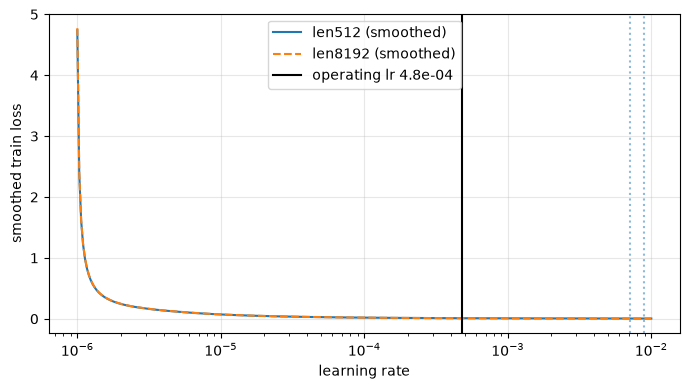

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
for res, style in [(res512, "-"), (res8k, "--")]:
    ax.plot(res["curve"]["lr"], res["curve"]["smoothed"], style,
            label=f"len{res['max_len']} (smoothed)")
    ax.axvline(res["lr_at_min_loss"], ls=":", alpha=0.5)
ax.axvline(OPERATING_LR, color="k", lw=1.5, label=f"operating lr {OPERATING_LR:.1e}")
ax.set_xscale("log"); ax.set_xlabel("learning rate"); ax.set_ylabel("smoothed train loss")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()